# Modeling Variance Threshold - Decision Tree - Hugo Fiévet

## Table of Contents

1. [Objective](#1-objective)
2. [Baseline Model](#2-baseline-model)
3. [Hyperparameter Tuning](#3-hyperparameter-tuning)
4. [Final Evaluation](#4-final-evaluation)
5. [Model Limits](#5-model-limits)

## 1. Objective

Établir une performance de référence du modèle avec ses paramètres par défaut avant optimisation des hyperparamètres.

## 2. Baseline Model

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_validate,GridSearchCV,StratifiedKFold
from sklearn.metrics import  accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

RANDOM_STATE = 42

dt =  DecisionTreeClassifier(random_state=RANDOM_STATE)

xtrain_VT = pd.read_csv("../data/selected/xtrain_VT.csv")
ytrain = pd.read_csv("../data/processed/ytrain.csv").squeeze("columns")

StratifiedKfold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = cross_validate(estimator=dt,X=xtrain_VT,y=ytrain,scoring="f1_macro",return_train_score=True,cv=StratifiedKfold_cv)
pd.DataFrame(cv_results)

,fit_time,score_time,test_score,train_score
0,0.482733,0.013952,0.669619,1.0
1,0.441196,0.012129,0.659290,1.0
2,0.400940,0.015888,0.678300,1.0
3,0.467260,0.013204,0.666033,1.0
4,0.482648,0.013109,0.654056,1.0


In [2]:
print("Mean train score : ",cv_results["train_score"].mean())
print("Mean validation score",cv_results["test_score"].mean())

Mean train score :  1.0
Mean validation score 0.6654597308299292


Le Decision Tree avec ses paramètres par défaut obtient un F1-macro moyen d’environ **0,665** en validation croisée, contre **1,000** sur l’entraînement.

L’écart entraînement–validation est donc d’environ **0,335**, ce qui met en évidence un surapprentissage important.

Cette baseline montre que l’arbre est trop complexe dans sa configuration par défaut et qu’une régularisation est nécessaire.

## 3. Hyperparameter Tuning

In [3]:
settings_grid = {
    "max_depth":[None,10,20],
    "min_samples_leaf":[1, 2, 5],
    "max_features":["sqrt", 0.5],
}

grid_search =  GridSearchCV(estimator=dt,param_grid=settings_grid,scoring="f1_macro",cv=StratifiedKfold_cv,return_train_score=True)

grid_search.fit(
    xtrain_VT,
    ytrain,
)


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 0.5], 'min_samples_leaf': [1, 2, ...]}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


In [4]:
best_index = grid_search.best_index_

print("Best parameters:", grid_search.best_params_)

print("Best validation F1:", grid_search.best_score_)
print(
    "Mean train F1:",
    grid_search.cv_results_["mean_train_score"][best_index]
)
print(
    "Std validation F1:",
    grid_search.cv_results_["std_test_score"][best_index]
)

Best parameters: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 5}
Best validation F1: 0.701421295002366
Mean train F1: 0.8179763561756337
Std validation F1: 0.008392757793429373


L’optimisation sélectionne `max_depth=10`, `max_features=0.5` et `min_samples_leaf=5`.

Le F1-macro moyen de validation atteint **0,701**, contre environ **0,665** pour la baseline. Le F1-macro moyen d’entraînement diminue à **0,818**.

L’écart entraînement–validation passe ainsi d’environ **0,335 à 0,117**. La régularisation réduit fortement le surapprentissage tout en améliorant la performance de validation.

L’écart-type du F1-macro de validation est d’environ **0,008**, ce qui indique une bonne stabilité entre les folds.

## 4. Final Evaluation

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
X_test_VT = pd.read_csv("../data/selected/xtest_VT.csv")
y_test = pd.read_csv("../data/processed/ytest.csv").squeeze("columns")

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X=X_test_VT)

class_report = classification_report(y_test, y_pred)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy :",accuracy )
print("Precision macro :",precision )
print("Recall macro :",recall )
print("F1 macro :", f1)

Accuracy : 0.7334030318870883
Precision macro : 0.7008435629262411
Recall macro : 0.7098435188560012
F1 macro : 0.7044815329951039


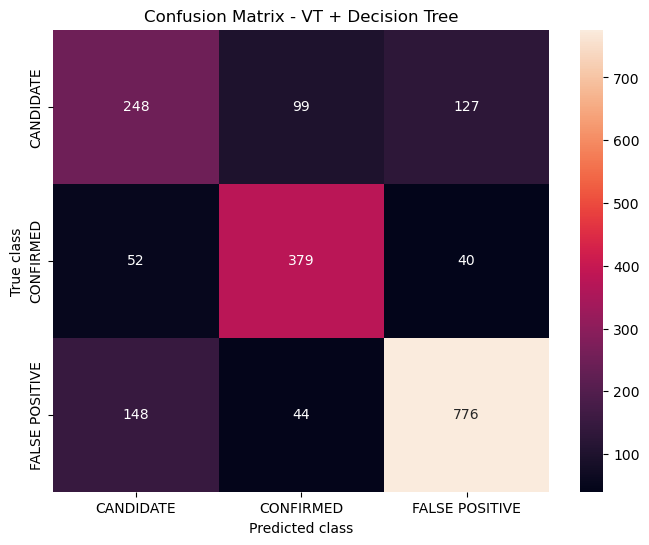

In [6]:
labels = ["CANDIDATE", "CONFIRMED", "FALSE POSITIVE"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix - VT + Decision Tree")

plt.show()

Sur le jeu de test indépendant, le Decision Tree optimisé avec Variance Threshold obtient :

- **Accuracy : 0,7334**
- **Precision macro : 0,7008**
- **Recall macro : 0,7098**
- **F1 macro : 0,7045**

Le F1-macro de test est très proche du score moyen obtenu en validation croisée (**0,7014**), ce qui indique une généralisation cohérente.

La régularisation améliore nettement le comportement de l’arbre par rapport à la baseline, même si ses performances restent inférieures à celles du Random Forest avec Variance Threshold.

## 5. Model Limits

Le Decision Tree avec Variance Threshold reste moins performant que le Random Forest, malgré l’utilisation d’un plus grand ensemble de variables. Cela montre qu’un nombre plus important de features ne garantit pas une meilleure classification. Le problème semble ici davantage lié à la capacité de généralisation d’un arbre unique qu’à la sélection des variables elle-même. Cette combinaison illustre donc l’intérêt de distinguer l’effet de la sélection de variables de celui de l’algorithme choisi.